In [17]:
# TODO: rewrite this as just a .py file?

In [18]:
"""
One-time script to preprocess raw UCSC XENA RNAseq data and save as a new csv
"""

'\nOne-time script to preprocess raw UCSC XENA RNAseq data and save as a new csv\n'

In [19]:
import pandas as pd

In [20]:
# Dataset is GDC TCGA BRCA via UCSC XENA 
# STAR TPM - RNAseq
# https://xenabrowser.net/datapages/?dataset=TCGA-BRCA.star_tpm.tsv&host=https%3A%2F%2Fgdc.xenahubs.net&removeHub=https%3A%2F%2Fxena.treehouse.gi.ucsc.edu%3A443

In [21]:
# ---- Gene Expression Data ----
# units are log2(tpm+1)

In [22]:
data = pd.read_csv("../data/raw/TCGA-BRCA.star_tpm.tsv", 
                            delimiter="\t", index_col=0)

data = data.transpose()     # now cols are genes, rows are samples
print(data.shape)

# Features - remove PAR_Y genes
par_y_genes = [x for x in data.columns if "PAR_Y" in x]
data.drop(columns=par_y_genes, inplace=True)

# Features - Ensembl IDs - strip the version number (after '.')
data.columns = data.columns.str.split('.').str[0]

data.head()

(1226, 60660)


Ensembl_ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,...,0.0,0.0,0.537346,0.0,0.000000,0.0,3.533999,0.0,0.058109,1.122739
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,...,0.0,0.0,0.204767,0.0,0.000000,0.0,4.773448,0.0,0.054779,1.243182
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,...,0.0,0.0,0.412402,0.0,0.000000,0.0,4.701710,0.0,0.093425,0.604261
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790,3.122375,4.754674,5.608738,3.625691,5.678199,...,0.0,0.0,0.268075,0.0,0.966357,0.0,4.689075,0.0,0.059771,0.536351
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548,1.508581,3.722149,5.224044,3.242221,5.956145,...,0.0,0.0,0.434028,0.0,0.000000,0.0,5.168221,0.0,0.023752,0.389126


In [23]:
# FILTER DATA to biologically meaningful examples

In [24]:
# STEP 1 - Only use primary tumor samples
# primary tumor is denoted as TCGA-xx-xxxx-01

rows_to_drop = [row for row in data.index if row[13:15] != '01']
data.drop(index=rows_to_drop, inplace=True)
data.head(15)

Ensembl_ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,...,0.0,0.000000,0.537346,0.0,0.000000,0.000000,3.533999,0.0,0.058109,1.122739
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,...,0.0,0.000000,0.204767,0.0,0.000000,0.000000,4.773448,0.0,0.054779,1.243182
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,...,0.0,0.000000,0.412402,0.0,0.000000,0.000000,4.701710,0.0,0.093425,0.604261
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790,3.122375,4.754674,5.608738,3.625691,5.678199,...,0.0,0.000000,0.268075,0.0,0.966357,0.000000,4.689075,0.0,0.059771,0.536351
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548,1.508581,3.722149,5.224044,3.242221,5.956145,...,0.0,0.000000,0.434028,0.0,0.000000,0.000000,5.168221,0.0,0.023752,0.389126
TCGA-AC-A62V-01A,3.536849,0.736475,6.823355,2.108324,2.277777,2.357299,2.899195,7.035671,2.984753,4.055118,...,0.0,0.000000,0.415975,0.0,0.000000,0.000000,3.140910,0.0,0.071900,1.212071
TCGA-AO-A0J5-01A,4.645690,1.255622,5.749910,4.487107,2.545178,2.954327,5.550208,5.923499,3.380480,5.442044,...,0.0,0.873892,0.264957,0.0,0.000000,0.000000,3.471331,0.0,0.051581,1.049979
TCGA-BH-A0B1-01A,6.021755,0.392647,6.977449,4.021000,3.372492,2.234195,5.319824,5.978889,5.085093,6.054527,...,0.0,0.000000,0.172872,0.0,0.000000,0.000000,4.392331,0.0,0.048655,0.436482
TCGA-A2-A0YM-01A,6.260931,0.467593,6.819887,3.319560,4.023974,4.159678,4.140615,5.898704,5.049156,7.221273,...,0.0,0.000000,0.247685,0.0,0.000000,0.022474,4.234333,0.0,0.055473,0.709467
TCGA-AO-A03N-01B,3.613025,0.000000,6.079559,2.287502,1.753177,1.117230,2.477962,5.277356,2.591225,4.855432,...,0.0,0.000000,0.108089,0.0,0.000000,0.000000,1.934517,0.0,0.000000,1.498710


In [27]:
# STEP 2 - only use protein-coding genes

# use GENCODE gene annotation table v23 to get gene types

gtf = pd.read_csv(
    "../data/gene_tables/gencode.v23.annotation.gtf",
    sep="\t",
    comment="#",
    header=None,
    names=[
        "chrom", "source", "feature",
        "start", "end", "score",
        "strand", "frame", "attributes"
    ]
)

# we only need info about genes
genes = gtf[gtf["feature"] == "gene"].copy()

# attributes look like key "value"; ...
# gene_id "ENSG00000183186.7"; gene_type "protein_coding"; ...
attributes_to_extract = ["gene_id", "gene_type", "gene_name"]

for new_col in attributes_to_extract:
    genes[new_col] = ""

for row in genes.itertuples():
    row_attributes = row.attributes.split(";")
    row_attributes = [a.strip() for a in row_attributes]    # remove spaces
    # copy desired attributes into their own columns
    for atr in row_attributes:
        for target in attributes_to_extract:
            if target in atr:
                key, val, end = atr.split('"')
                key = key.strip()
                if key in attributes_to_extract:
                    genes.at[row.Index, key] = val

# strip version numbers from gene_ids again
genes["gene_id"] = [g.split('.')[0] for g in genes["gene_id"]]

genes.head(n=9)
genes.to_csv("../data/processed/gene_table.csv")

genes_name_type = genes[["gene_id", "gene_name", "gene_type"]]
genes_name_type.to_csv("../data/processed/gene_names_types.csv")

In [28]:
# Drop genes (columns) that aren't protein_coding

# create a dict mapping gene_id to gene_type for convenience
gene_type_dict = dict(zip(genes["gene_id"], genes["gene_type"]))

cols_to_drop = [gene_id for gene_id in data.columns
                if gene_id not in gene_type_dict.keys()
                or gene_type_dict[gene_id] != "protein_coding"]

print("Dropping", len(cols_to_drop), "non-protein-coding columns")

data.drop(columns=cols_to_drop, inplace=True)
data.head()


Dropping 41103 non-protein-coding columns


Ensembl_ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000281991,ENSG00000282034,ENSG00000282218,ENSG00000282246,ENSG00000282278,ENSG00000282301,ENSG00000282419,ENSG00000282608,ENSG00000282804,ENSG00000282815
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.385983,0.0,0.000000
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.495900,0.0,0.000000
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.897357,0.0,0.000000
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790,3.122375,4.754674,5.608738,3.625691,5.678199,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.383110,0.0,0.000000
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548,1.508581,3.722149,5.224044,3.242221,5.956145,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.833052,0.0,0.022474


In [29]:
# STEP 3 - Remove low-expression genes
# with log2(TPM + 1) units, expression < 1.0 is weak
# so only use genes with expression > 1.0 in at least 10% of samples

# for each column (gene)
# count number of samples with expr > 1.0
# if proportion not >= 10%, drop column

low_expression_cols = []

for gene in data.columns:
    all_samples = data[gene].tolist()
    strong_expression = [x for x in all_samples if x > 1.0]
    proportion = len(strong_expression) / len(all_samples)
    if proportion < 0.10:
        low_expression_cols.append(gene)

print("Dropping", len(low_expression_cols), "low expression columns")

data.drop(columns=low_expression_cols, inplace=True)
data.head()

Dropping 4335 low expression columns


Ensembl_ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000279483,ENSG00000279968,ENSG00000280071,ENSG00000280116,ENSG00000280433,ENSG00000280649,ENSG00000280670,ENSG00000280789,ENSG00000281571,ENSG00000282608
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,...,8.334575,0.653427,1.389512,1.617722,1.572599,2.551344,2.334111,4.162178,1.525568,3.385983
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,...,8.560735,0.622274,0.679784,0.314290,1.079156,0.955164,1.247016,3.164143,0.080112,3.495900
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,...,8.562955,0.907660,1.314232,1.058178,1.284929,0.176833,1.477781,3.588637,0.059771,2.897357
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790,3.122375,4.754674,5.608738,3.625691,5.678199,...,9.802919,0.302524,0.869871,0.752406,1.075670,0.580145,2.793043,3.192384,0.214747,3.383110
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548,1.508581,3.722149,5.224044,3.242221,5.956145,...,9.358765,0.444561,0.404031,0.702658,0.982510,0.105142,3.799999,2.826335,0.052138,2.833052


In [30]:
# STEP 4 - Variance Filtering
# only keep the top 75% most variable genes
# to improve neural network performance

low_variance_cols = []

variances = data.var(axis=0)
sorted_variances = variances.sort_values()

cutoff = int(len(data.columns)*0.25)    # lower quartile index; drop any below

low_variance_cols = sorted_variances[:cutoff].index

print("Dropping", len(low_variance_cols), "low-variance columns")

filtered_data = data.drop(columns=low_variance_cols)
filtered_data.head()

Dropping 3794 low-variance columns


Ensembl_ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000278828,ENSG00000278845,ENSG00000279386,ENSG00000279457,ENSG00000279461,ENSG00000279483,ENSG00000280649,ENSG00000280670,ENSG00000280789,ENSG00000282608
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,...,2.410938,5.473212,1.578746,2.756831,0.000000,8.334575,2.551344,2.334111,4.162178,3.385983
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,...,4.587035,7.532036,1.971847,1.959177,0.000000,8.560735,0.955164,1.247016,3.164143,3.495900
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,...,0.739243,6.626841,0.230572,1.821833,0.000000,8.562955,0.176833,1.477781,3.588637,2.897357
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790,3.122375,4.754674,5.608738,3.625691,5.678199,...,3.608312,6.260033,2.172103,2.857583,1.351459,9.802919,0.580145,2.793043,3.192384,3.383110
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548,1.508581,3.722149,5.224044,3.242221,5.956145,...,5.759364,6.476375,1.565012,1.502178,1.874600,9.358765,0.105142,3.799999,2.826335,2.833052


In [31]:
# We are now done removing features

# STEP 5 - Standardize Features
# We will standardize gene expression values per-gene (mean=0, variance=1)
# to improve neural network performance

std_data = filtered_data.copy()

for col in std_data.columns:
    if col != "Ensembl_ID":
        std_data[col] = (std_data[col] - std_data[col].mean()) / std_data[col].std()

std_data.head()

Ensembl_ID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000278828,ENSG00000278845,ENSG00000279386,ENSG00000279457,ENSG00000279461,ENSG00000279483,ENSG00000280649,ENSG00000280670,ENSG00000280789,ENSG00000282608
TCGA-D8-A146-01A,0.609921,2.327864,0.087585,0.818368,-0.121749,0.446894,0.691725,-0.180689,0.655876,0.377663,...,-0.866894,-1.242985,0.285248,0.638094,-1.105723,-0.429549,0.818009,-0.069509,0.795393,0.569034
TCGA-AQ-A0Y5-01A,-1.315849,-0.416274,0.451240,0.310235,-0.679990,-0.938950,0.643528,1.310939,0.185182,0.189319,...,0.320396,1.369754,0.841154,-0.530014,-1.105723,-0.237886,-0.797377,-1.517845,-0.648637,0.691386
TCGA-C8-A274-01A,1.448231,-0.852528,-0.000902,1.743955,1.477604,-1.157396,-1.153266,-0.979064,-0.697934,0.548966,...,-1.778979,0.221021,-1.621278,-0.731145,-1.105723,-0.236005,-1.585072,-1.210397,-0.034448,0.025129
TCGA-BH-A0BD-01A,-0.252621,1.340581,-0.582592,0.781180,1.637184,-0.057358,0.469251,-0.190282,-0.398541,0.141472,...,-0.213600,-0.244474,1.124348,0.785638,0.427632,0.814822,-1.176908,0.541926,-0.607776,0.565836
TCGA-B6-A1KC-01B,-0.776697,-0.442353,-1.007828,-0.405774,-0.462985,-1.835713,-0.481901,-0.811034,-0.930591,0.538124,...,0.960024,0.030074,0.265827,-1.199256,1.021184,0.438417,-1.657627,1.883493,-1.137402,-0.046451


In [32]:
# Gene expression data is now processed
std_data.shape

(1106, 11384)

In [33]:
# ---- Survival Data ----

In [35]:
survival = pd.read_csv("../data/raw/TCGA-BRCA.survival.tsv", delimiter="\t", index_col=0)
print(survival.shape)
survival.head()

(1232, 3)


,OS.time,OS,_PATIENT
sample,,,
TCGA-C8-A275-01A,1.0,0,TCGA-C8-A275
TCGA-AC-A7VC-01A,1.0,0,TCGA-AC-A7VC
TCGA-BH-A1F8-01A,1.0,1,TCGA-BH-A1F8
TCGA-BH-A1F8-11B,1.0,1,TCGA-BH-A1F8
TCGA-PL-A8LX-01A,5.0,0,TCGA-PL-A8LX


In [36]:
# STEP 6 - Filter Survival Samples
# We only want primary tumor samples, and one per patient (xx-01A)

rows_to_drop = [row for row in survival.index if row[13:16] != '01A']
survival.drop(index=rows_to_drop, inplace=True)

# Ensure no duplicates
print("Shape = ", survival.shape)
print("Unique patients = ", len(survival["_PATIENT"].unique()))

survival.head()

Shape =  (1064, 3)
Unique patients =  1064


,OS.time,OS,_PATIENT
sample,,,
TCGA-C8-A275-01A,1.0,0,TCGA-C8-A275
TCGA-AC-A7VC-01A,1.0,0,TCGA-AC-A7VC
TCGA-BH-A1F8-01A,1.0,1,TCGA-BH-A1F8
TCGA-PL-A8LX-01A,5.0,0,TCGA-PL-A8LX
TCGA-C8-A1HJ-01A,5.0,0,TCGA-C8-A1HJ


In [37]:
# STEP 7 - Align Survival with Gene Data

final_data = std_data.join(survival, how='inner')
final_data.drop(columns=["_PATIENT"], inplace=True)

print(final_data.shape)
final_data.head()

(1059, 11386)


,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000279386,ENSG00000279457,ENSG00000279461,ENSG00000279483,ENSG00000280649,ENSG00000280670,ENSG00000280789,ENSG00000282608,OS.time,OS
TCGA-D8-A146-01A,0.609921,2.327864,0.087585,0.818368,-0.121749,0.446894,0.691725,-0.180689,0.655876,0.377663,...,0.285248,0.638094,-1.105723,-0.429549,0.818009,-0.069509,0.795393,0.569034,643.0,0
TCGA-AQ-A0Y5-01A,-1.315849,-0.416274,0.451240,0.310235,-0.679990,-0.938950,0.643528,1.310939,0.185182,0.189319,...,0.841154,-0.530014,-1.105723,-0.237886,-0.797377,-1.517845,-0.648637,0.691386,172.0,1
TCGA-C8-A274-01A,1.448231,-0.852528,-0.000902,1.743955,1.477604,-1.157396,-1.153266,-0.979064,-0.697934,0.548966,...,-1.621278,-0.731145,-1.105723,-0.236005,-1.585072,-1.210397,-0.034448,0.025129,508.0,0
TCGA-BH-A0BD-01A,-0.252621,1.340581,-0.582592,0.781180,1.637184,-0.057358,0.469251,-0.190282,-0.398541,0.141472,...,1.124348,0.785638,0.427632,0.814822,-1.176908,0.541926,-0.607776,0.565836,554.0,0
TCGA-AC-A62V-01A,-1.479948,-0.158745,0.028476,-2.513840,-0.879178,-0.900450,-1.239999,2.112255,-1.287818,-2.174797,...,-1.723977,0.057250,0.482386,0.134892,-0.804624,-1.049679,1.439781,1.250206,348.0,1


In [39]:
# Save final data
final_data.to_csv("../data/processed/data.csv")

In [41]:
# Descriptive stats
final_data.describe()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000279386,ENSG00000279457,ENSG00000279461,ENSG00000279483,ENSG00000280649,ENSG00000280670,ENSG00000280789,ENSG00000282608,OS.time,OS
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,...,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000
mean,0.012660,-0.001132,0.016577,-0.007150,-0.007142,0.012172,0.006805,0.013190,0.006787,0.007961,...,-0.030824,0.017273,-0.048411,0.057045,0.009904,0.001746,0.011997,0.000925,1249.187913,0.139754
std,0.998920,0.981608,0.975560,0.994682,0.994946,0.989947,0.995658,0.969565,0.994948,1.003921,...,0.975820,0.989277,0.905436,0.827555,0.996769,0.996528,0.993605,1.002673,1190.735561,0.346896
min,-3.814994,-0.852528,-4.814185,-4.012521,-3.265386,-2.666545,-3.514040,-5.416175,-3.421545,-4.317752,...,-1.947342,-2.538653,-1.105723,-3.303819,-1.764033,-2.654364,-3.314923,-2.936935,1.000000,0.000000
25%,-0.568770,-0.687028,-0.519299,-0.618438,-0.599831,-0.685994,-0.616869,-0.574522,-0.612702,-0.569479,...,-0.751149,-0.709178,-1.105723,-0.380660,-0.787807,-0.737339,-0.634423,-0.649663,456.500000,0.000000
50%,0.090307,-0.378261,-0.045376,0.029822,-0.012047,-0.015219,0.110080,-0.043402,-0.025138,0.045546,...,-0.101818,-0.024382,-0.061046,0.091542,-0.043134,-0.065093,0.048201,0.056800,852.000000,0.000000
75%,0.688613,0.358641,0.535287,0.658699,0.618176,0.639390,0.689974,0.616925,0.606644,0.602196,...,0.644475,0.693088,0.591774,0.541877,0.676805,0.654511,0.669416,0.727163,1682.500000,0.000000
max,4.293016,6.934354,5.063719,3.046541,4.678390,4.090284,3.871139,5.299883,3.951367,6.015436,...,3.920007,3.212973,2.545930,2.753328,3.976698,3.100921,3.071521,2.651462,8605.000000,1.000000


<Axes: xlabel='OS.time', ylabel='Count'>

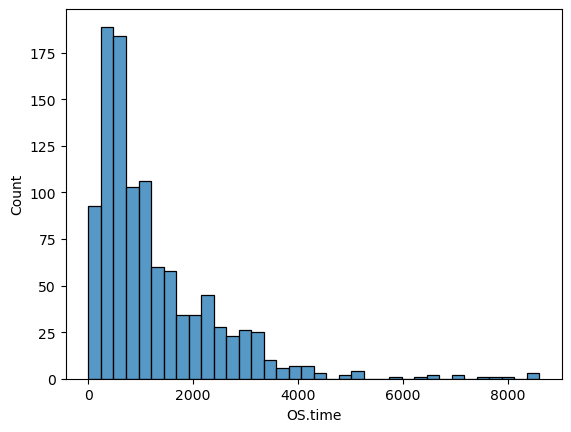

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(final_data, x="OS.time")

In [50]:
print(len(final_data[final_data["OS"] == 0]))
print(len(final_data[final_data["OS"] == 1]))

911
148


<Axes: xlabel='OS', ylabel='Count'>

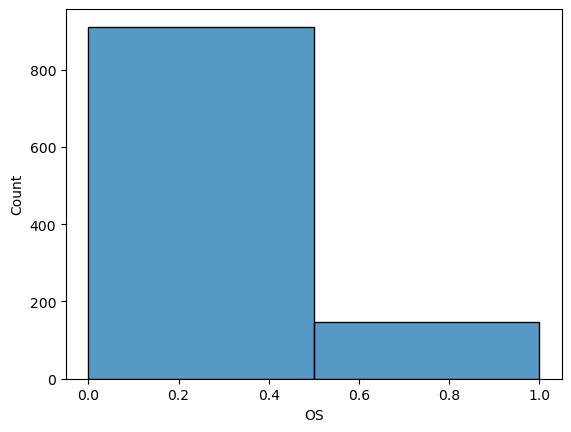

In [56]:
sns.histplot(final_data, x="OS", bins=[0, 0.5, 1])